In [53]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict,Annotated,Literal
from pydantic import BaseModel,Field
from operator import add

In [54]:
load_dotenv()

llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0
)


In [55]:
## create a structured model for tweet evaluation

class TweetEvaluation(BaseModel):
    status: Literal['approved','needs_improvement'] = Field(
         description="Whether the tweet is approved or needs improvement"
    )

    feedback: str = Field(
         description="Specific feedback explaining why the tweet was approved or rejected"
    )

evaluator_llm = llm.with_structured_output(TweetEvaluation,method = 'json_schema')


class OptimizedTweet(BaseModel):
    tweet: str = Field(
         description="The improved X/Twitter tweet"
    )

optimized_llm = llm.with_structured_output(OptimizedTweet,method = 'json_schema')



 

In [56]:
## states

class State(TypedDict):
    topic: str
    tweet: str
    status: str
    feedback: str
    iteration: int
    history: Annotated[list,add]
    final_status: str

In [57]:
## Tweet Generator node

def generate_tweet(state: State):
    prompt = f"""
    Generate a high-quality X/Twitter post about the following topic:

    Topic: {state['topic']}
     Requirements:
    - Maximum 280 characters
    - Engaging
    - Clear and concise
    - Natural human-like writing
    - Strong hook
    - No unnecessary hashtags
    - Suitable for X/Twitter

    Return only the tweet.
    """



    response = llm.invoke(prompt)
    tweet = response.content.strip()

    return{
        'tweet': tweet,
        'iteration': 1
    }


In [58]:
## now make a node(python function) for evaluation

def evaluate_tweet(state: State):
    prompt = f"""
    Evaluate the following X/Twitter tweet.

    Tweet: {state['tweet']}

     Check:

    1. Is it engaging?
    2. Is the hook strong?
    3. Is it clear?
    4. Is it concise?
    5. Is it useful or interesting?
    6. Is it suitable for X/Twitter?
    7. Is it within 280 characters?
    8. Does it sound natural?

    If the tweet is good enough, return:
    approved

    Otherwise return:
    needs_improvement

    Give specific feedback explaining your decision.
    """

    response = evaluator_llm.invoke(prompt)

    return{
        'status': response.status,
        'feedback': response.feedback,
        'history':[
            {
                'iteration': state['iteration'],
                'tweet': state['tweet'],
                'status': response.status,
                'feedback': response.feedback
            }
        ]
    }


In [59]:
## now use a router 

def tweet_router(state: State):
    if state['status'] == 'approved':
        return 'approved'

    if state['iteration']>=5:
        return 'max_iterations'

    return 'needs_improvement'

    

In [60]:
## now node (python function ) for optimized

def optimize_tweet(state: State):
    prompt = f"""
    Improve the following X/Twitter tweet.

    Original Tweet:
    {state['tweet']}

    Evaluator Feedback:
    {state['feedback']}

    Requirements:
    - Fix the problems mentioned in the feedback
    - Make the hook stronger
    - Make the tweet engaging
    - Keep it clear and concise
    - Keep it natural
    - Maximum 280 characters
    - Do not explain your changes
    - Return only the improved tweet

    Improve the tweet based specifically on the evaluator feedback.
    """

    response = optimized_llm.invoke(prompt)

    return{
        'tweet': response.tweet.strip(),
        'iteration': state['iteration']+ 1
    }




In [61]:
##node for final_status

def final_status(state: State):
    if state['status'] == 'approved':
        return{
            'final_status': 'approved'
        }

    return{
        'final_status': 'max_iterations_reached'
    }

In [62]:
graph = StateGraph(State)

graph.add_node('generate_tweet',generate_tweet)
graph.add_node('evaluate_tweet',evaluate_tweet)
graph.add_node('optimize_tweet',optimize_tweet)
graph.add_node('final_status',final_status)


graph.add_edge(START,'generate_tweet')
graph.add_edge('generate_tweet','evaluate_tweet')

## now apply conditional routing

graph.add_conditional_edges(
    'evaluate_tweet',
    tweet_router,{
        'approved': 'final_status',
        'needs_improvement': 'optimize_tweet',
        'max_iterations': 'final_status'
    }

)

graph.add_edge('optimize_tweet','evaluate_tweet')

graph.add_edge('final_status',END)


workflow = graph.compile()

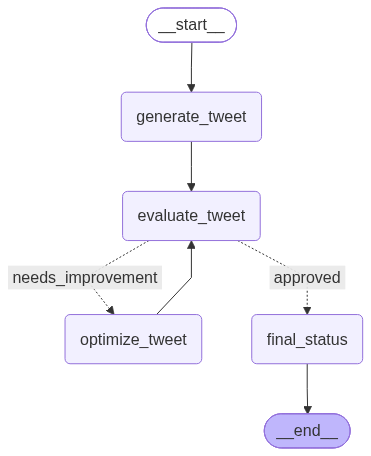

In [63]:
workflow

In [68]:
topic = "AI will completely replace software developers within the next 5 years."

result = workflow.invoke({
    'topic': topic
})

result

{'topic': 'AI will completely replace software developers within the next 5 years.',
 'tweet': 'Imagine a world where your code writes itself. In 5 years, AI could replace every software developer—no more debugging, no more manual coding. The future of tech isn’t about who writes code, but who trains the AI. Are we ready to hand over the keyboard?',
 'status': 'approved',
 'feedback': 'The tweet is engaging, with a strong hook that sparks curiosity. It is clear, concise (252 characters), and stays within the 280‑character limit. The message is relevant and interesting for a tech audience, and it reads naturally for X/Twitter.',
 'iteration': 1,
 'history': [{'iteration': 1,
   'tweet': 'Imagine a world where your code writes itself. In 5 years, AI could replace every software developer—no more debugging, no more manual coding. The future of tech isn’t about who writes code, but who trains the AI. Are we ready to hand over the keyboard?',
   'status': 'approved',
   'feedback': 'The twe